Text(0.5, 1.0, 'Count of Defect Classes Validation Set')

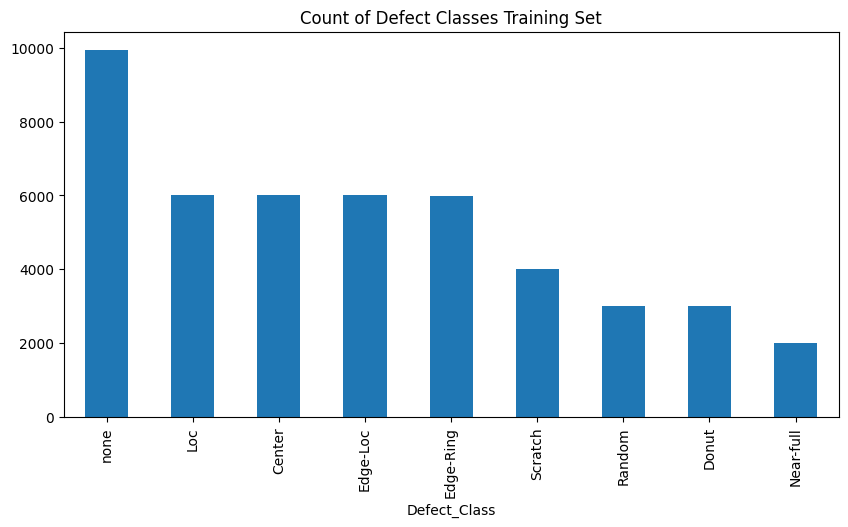

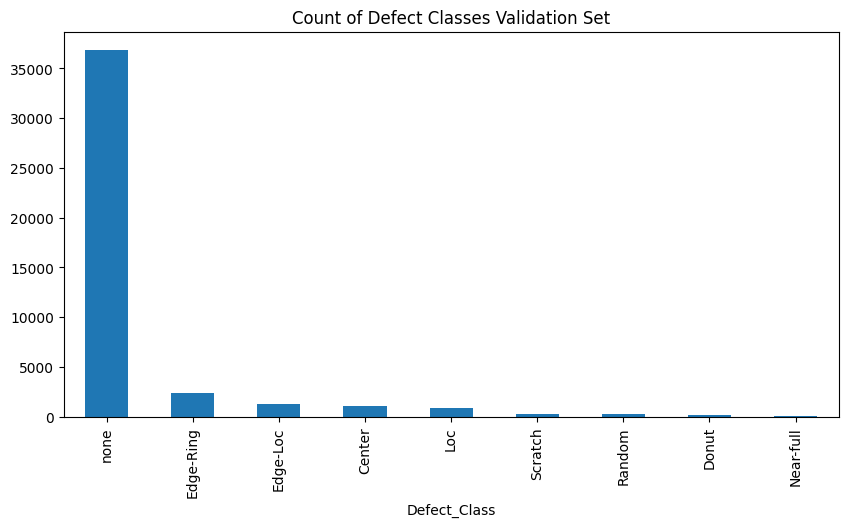

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Import Clean data
clean_df = pd.read_pickle("train_set.pkl")
val_df = pd.read_pickle("val_set.pkl")

# Visualize count of each class in Defect_Class
plt.figure(figsize=(10,5))
clean_df['Defect_Class'].value_counts().plot(kind='bar')
plt.title('Count of Defect Classes Training Set')

# Visualize count of each class in Defect_Class
plt.figure(figsize=(10,5))
val_df['Defect_Class'].value_counts().plot(kind='bar')
plt.title('Count of Defect Classes Validation Set')

### kNN Model

C:\Users\Kaustubh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=20. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits
Training Time: 5.985658407211304 seconds
Training Accuracy: 0.9715
Evaluation Time: 2.0393943786621094 seconds
              precision    recall  f1-score   support

      Center       0.19      0.51      0.28      1074
       Donut       0.03      0.32      0.06       139
    Edge-Loc       0.07      0.16      0.10      1297
   Edge-Ring       0.38      0.89      0.53      2420
         Loc       0.06      0.19      0.09       898
   Near-full       0.86      1.00      0.93        37
      Random       0.54      0.74      0.63       217
     Scratch       0.01      0.07      0.02       298
        none       0.95      0.66      0.78     36857

    accuracy                           0.64     43237
   macro avg       0.34      0.50      0.38     43237
weighted avg       0.84      0.64      0.71     43237

Best Hyperparameters: {'weights': 'distance', 'n_neighbors': 45, 'metric': 'manhattan'}


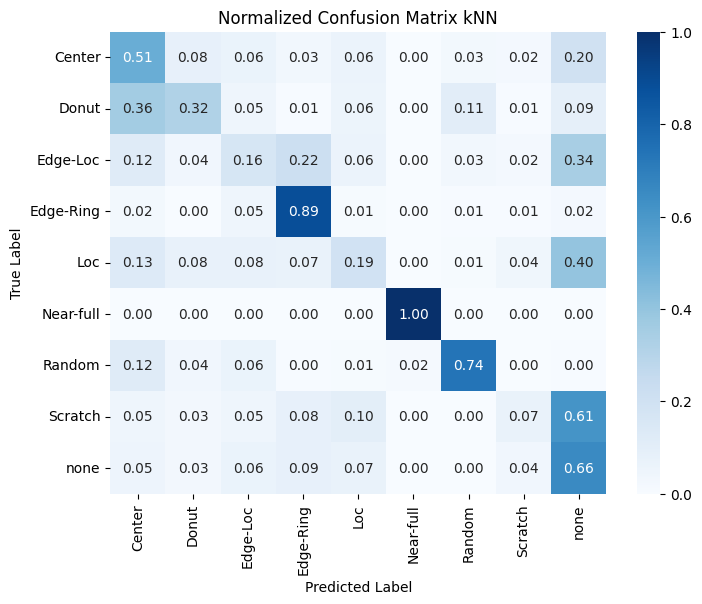

In [2]:
import numpy as np
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# Define feature columns
region_features = [f"Region_{i}" for i in range(1, 26)]
radial_features = [f"Radial_Zone_{i}" for i in range(1, 7)]
total_defects = ['Total_Defect_Density']
features = region_features + radial_features + total_defects

# Define target variable
X_train = clean_df[features]  
y_train = clean_df['Defect_Class']  
X_test = val_df[features]  
y_test = val_df['Defect_Class']  

# Define kNN classifier
knn = KNeighborsClassifier()

# Define hyperparameter grid for tuning
param_grid = {
    "n_neighbors": [45], 
    "weights": ["distance"],
    "metric": ["manhattan"] 
}

# Set up RandomizedSearchCV for hyperparameter tuning
random_search = RandomizedSearchCV(
    knn, param_distributions=param_grid, 
    n_iter=20, cv=3, scoring='accuracy', 
    n_jobs=-1, verbose=2, random_state=1
)

# Start Time
import time
start = time.time()

# Fit the model
random_search.fit(X_train, y_train)

# End Time
end = time.time()
print(f"Training Time: {end - start} seconds")

# Get the best model
best_knn = random_search.best_estimator_
train_accuracy = best_knn.score(X_train, y_train)
print(f"Training Accuracy: {train_accuracy:.4f}")

# Make predictions
start = time.time()
y_pred = best_knn.predict(X_test)
end = time.time()
print(f"Evaluation Time: {end - start} seconds")
# Print classification report
print(classification_report(y_test, y_pred))

# Print best hyperparameters
print("Best Hyperparameters:", random_search.best_params_)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=best_knn.classes_)

# Normalize the confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot the normalized confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=best_knn.classes_, yticklabels=best_knn.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalized Confusion Matrix kNN')
plt.show()

# Compute accuracy for each defect class
class_accuracies = cm.diagonal() / cm.sum(axis=1)

# Convert to DataFrame for readability
accuracy_df = pd.DataFrame(class_accuracies, index=best_knn.classes_, columns=['Accuracy'])
accuracy_df = accuracy_df.sort_values('Accuracy', ascending=False)